# Computer Exercise 15.33 — Problem 2
## 잠정 주장의 확정 시도 — `fix_big` $>$ `base` 와 **승자의 저주**

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.33
> **단원**: Ch 15 Sequential Decision Making — §15.33 Adjudicating a Provisional Claim
> **풀이 일자**: 2026-08-18 (Day 100)
> **언어**: Python 3.10 · NumPy / pandas / SciPy / Matplotlib
>
> Day 99 P2 는 여덟 arm 을 20 시드로 비교해 **`fix_big`** ($\sigma \equiv 0.55$ 로 동결한
> 균일 파라미터 잡음) 이 이겼다고 보고했고, P3 은 `fix_big` $-$ `base` $= +0.0487$ 을
> "CI 는 0 을 배제하나 $n^\dagger > 40$ 이므로 **잠정**" 으로 남겼다. 이것은 Ch 15 에서
> baseline 을 넘은 **유일한** 후보다.
>
> Problem 1 이 정한 프로토콜 v2 를 처음으로 적용한다. 그리고 v2 가 요구하는 것 중 Day 99 가
> 하지 않은 일을 한다 — **사전 명시**. 아래 [사전 명시] 셀은 어떤 자료도 보기 전에
> 가설·가족·규칙·표본 크기를 못박는다. 그 다음에만 자료를 만든다.

## 1. 문제 (원문)

> **Computer Exercise 15.33.2.** Exercise 15.32 left one claim provisional: the frozen large-noise
> control (`fix_big`, $\sigma \equiv 0.55$) beats the $\varepsilon$-greedy baseline by $+0.0487$
> in mean deployment return, with a bootstrap interval excluding zero at $n = 20$ but a required
> sample size $n^\dagger > 40$. Adjudicate it under the calibrated protocol of Exercise 15.33.1.
> Pre-register the hypothesis family before generating data. Use an independent seed pool of at
> least $n = 60$, at least two control arms, the sign-flip permutation test as the primary rule,
> and Holm–Bonferroni over the pre-specified family. Perform the mandated A/A check.
> Then pool the independent evidence and test, in addition to the null $\delta = 0$, the
> **point null $\delta = 0.0487$** implied by Exercise 15.32. Quantify how much of any discrepancy
> is attributable to selection: the arm was chosen as the winner of an eight-way comparison.

### 한국어 풀이용 정리

두 개의 질문을 분리해야 한다. 지난 30 일이 이 둘을 섞어 왔다.

| 질문 | 귀무 | 답이 "예" 일 때의 의미 |
|---|---|---|
| **Q1. 효과가 있는가?** | $\delta = 0$ | `fix_big` 이 baseline 과 다르다 |
| **Q2. 효과가 그만큼인가?** | $\delta = 0.0487$ | Day 99 가 보고한 **크기**가 맞다 |

Day 99 는 Q1 만 물었다. 그런데 실무에서 중요한 것은 대개 Q2 다 — "이긴다" 가 아니라
"이 정도 이긴다" 여야 무언가를 결정할 수 있다. 그리고 **Q1 은 참인데 Q2 는 거짓** 인 경우가
매우 흔하며, 그 흔함에는 이름이 있다.

### 승자의 저주 (winner's curse)

$m$ 개 arm 을 재고 가장 좋은 것을 고른 뒤, **고를 때 쓴 바로 그 자료로** 효과 크기를 보고하면
그 추정치는 체계적으로 부풀려진다. 참 효과가 모두 $\delta$ 로 같고 각 추정치가
$\hat\delta_j \sim \mathcal N(\delta, s^2)$ 이면

$$\mathbb E\big[\max_j \hat\delta_j\big] - \delta \;=\; s \cdot \mathbb E\big[\max_j Z_j\big]
\;\approx\; s\sqrt{2\ln m}\quad (Z_j \sim \mathcal N(0,1)),$$

$m = 8$ 에서 $\mathbb E[\max_j Z_j] \approx 1.42$. Day 99 의 $n=20$, 시드 표준편차를 $s_d$ 라 하면
부풀림의 크기는 $1.42\,s_d/\sqrt{20}$ 이다. **이 값을 계산해 두고, 실측된 축소와 비교한다.**

## 2. 수학적 배경

### 2.1 점 귀무에 대한 순열검정

$\delta_0 \ne 0$ 인 귀무 $H_0: \delta = \delta_0$ 는 자료를 이동시켜 검정한다.
$\tilde d_i = d_i - \delta_0$ 로 두면 $H_0$ 아래 $\tilde d$ 는 0 대칭이므로 부호뒤집기 검정이
그대로 적용된다:

$$p(\delta_0) = \frac{1 + \#\big\{b : |\overline{s^{(b)}\tilde d}| \ge |\bar{\tilde d}|\big\}}{B+1}.$$

$\delta_0$ 를 격자 위에서 훑어 $p(\delta_0) > \alpha$ 인 집합을 모으면 **검정을 반전시킨**
신뢰구간이 나온다. 이 구간은 1 차 규칙과 **정확히 정합**한다 — Problem 1 이 bootstrap 구간을
보고 전용으로 강등한 이상, 판정과 구간이 같은 규칙에서 나오게 하는 것이 옳다.

$$\boxed{\;\mathrm{CI}_{1-\alpha} = \{\delta_0 : p(\delta_0) > \alpha\}\;}$$

### 2.2 사전 명시된 가족과 Holm

가족을 자료를 본 뒤에 정하면 $m$ 이 자료에 의존해 Holm 의 보장이 깨진다.
v2 는 가족을 **자료 생성 전에** 고정할 것을 요구한다. 이 노트북의 가족은 $m = 3$:

$$\mathcal F = \big\{\ \delta_1 = \mu_{\texttt{fix\_big}} - \mu_{\texttt{base}},\quad
\delta_2 = \mu_{\texttt{fix\_small}} - \mu_{\texttt{base}},\quad
\delta_3 = \mu_{\texttt{fix\_big}} - \mu_{\texttt{fix\_small}}\ \big\}$$

$\delta_1$ 이 1 차 주장이고, $\delta_2,\delta_3$ 은 그것을 해석 가능하게 만드는 통제군 비교다.
$\delta_1 > 0$ 인데 $\delta_2 \approx 0$ 이고 $\delta_3 > 0$ 이면 "이득은 잡음의 **크기**에서
온다" 가 되고, $\delta_1 \approx \delta_2$ 이면 "잡음의 존재 자체" 가 된다.

### 2.3 용량 항등성 (통제군 2)

Day 99 P1 의 보조정리를 그대로 통제군으로 쓴다. Factorized Noisy Linear 헤드에서
$\varepsilon_W \equiv 0$ 이면 $\partial\mathcal L/\partial\sigma_W = (\partial\mathcal L/\partial W^{\text{eff}})\odot\varepsilon_W = 0$
이므로 $\sigma$ 는 갱신되지 않고 순전파는 baseline 과 같다. 따라서

$$\mathbb E[R_{\texttt{inert}}] - \mathbb E[R_{\texttt{base}}] = 0 \quad\text{(항등식)}$$

이며 이 통제군은 **실험이 아니라 구현 검증**이다. 60 시드를 쓸 필요 없이 assert 로 충분하다.

### 2.4 증거의 결합과 축소량

독립 풀 $A$ (Problem 1 의 80 시드) 와 $B$ (이 노트북의 60 시드) 의 짝지은 차를 이어붙여
$n_A + n_B$ 개의 독립 관측으로 다룬다. Day 99 의 추정치 $\hat\delta_{99}$ 와 결합 추정치
$\hat\delta_{\text{pool}}$ 의 차

$$\Delta_{\text{shrink}} = \hat\delta_{99} - \hat\delta_{\text{pool}}$$

를 승자의 저주 예측 $1.42\,s_d/\sqrt{20}$ 과 대조한다. 두 값이 맞으면 Day 99 의 과대추정은
**설명되는 현상**이지 오류가 아니다 — 다만 그 사실을 알고 보고했어야 한다.

## 3. 풀이 흐름

1. **사전 명시** — 자료를 만들기 전에 가설·가족·규칙·$n$·통제군을 셀 하나에 못박고 출력한다.
2. **통제군 2 검증** — 용량 항등성 assert (2.3). 실패하면 이후 수치는 무의미하므로 정지.
3. **자료 생성** — 새 시드 $\{100201,\dots,100260\}$ (60 개) × 세 arm (`base`, `fix_big`,
   `fix_small`), $T = 10^4$. 배포는 시드 인덱스에만 의존 → 공통난수.
4. **A/A 점검** (v2 필수) — 같은 자료의 `base` arm 에서 N1 형 재무작위화 귀무로 1 차 규칙의
   기각률을 재고 명목 $0.05$ 근처인지 확인.
5. **1 차 판정** — 가족 $\mathcal F$ 의 세 비교에 순열 $p$, Holm 보정, 검정 반전 CI, $n^\star$.
6. **독립 증거 결합** — Problem 1 의 80 시드 풀을 재생성해 이어붙이고 $n = 140$ 으로 재판정.
7. **Q2 — 점 귀무 $\delta = 0.0487$** 검정, 그리고 검정 반전 CI 로 Day 99 의 크기가 배제되는지.
8. **승자의 저주 정량화** — $m=8$, $n=20$ 선택 하의 부풀림을 MC 로 예측하고 실측 축소와 대조.
9. **그림** — (Fig 1) 세 비교의 forest plot + 시드별 차. (Fig 2) 증거 누적과 승자의 저주 분포.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t as tdist

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–99 과 동일 계열의 5-상태 chain MDP 재구성) ──────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)          # 0.125 — Noisy 헤드 sigma 의 초기값
SIG_BIG  = 0.55                          # Day 99 P2 의 fix_big (학습 종점에 맞춘 값)

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a                      # slip
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

ARM_SPEC = {           # explore_noise, learn_sigma, inject_noise
    "base":  (False, False, False),
    "cnrt":  (True,  True,  True),
    "fixed": (True,  False, True),
    "inert": (False, False, False),
}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head. Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_decay=0.0, anneal=False, h=H,
                 sigma_init=None, sigma_pattern=None, mean_target=None):
        self.h, self.arm = h, arm
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.sigma_decay, self.anneal, self.scale = sigma_decay, anneal, 1.0
        self.mean_target = mean_target        # None 이면 제약 없음 (자유 학습)
        # 초기화 난수 소비 순서는 arm 과 무관 -> 모든 arm 이 같은 초기 가중치
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, h), sigma_init)
        self.bs = np.full(NA, sigma_init)
        if sigma_pattern is not None:         # 좌표별 sigma 를 외부에서 지정 (fix_het)
            self.Ws = sigma_pattern[0].copy(); self.bs = sigma_pattern[1].copy()
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def sigma_mean(self):
        return (self.Ws.sum() + self.bs.sum()) / (self.Ws.size + self.bs.size)

    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))   # factorized noise
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:
            self.Ws -= ETA * (gW2 * self.eps_W * self.scale + self.sigma_decay * self.Ws)
            self.bs -= ETA * (gb2 * self.eps_b * self.scale + self.sigma_decay * self.bs)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)
            if self.mean_target is not None:      # ★ 평균 고정 제약 (배분만 학습)
                m = self.sigma_mean()
                if m > 1e-12:
                    r = self.mean_target / m
                    self.Ws *= r; self.bs *= r

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_decay=0.0, anneal=False,
          sigma_init=None, sigma_pattern=None, mean_target=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_decay=sigma_decay, anneal=anneal,
                 sigma_init=sigma_init, sigma_pattern=sigma_pattern, mean_target=mean_target)
    lr.trace = []
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if lr.anneal: lr.scale = 1.0 - t / T
        if lr.explore_noise:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, float(lr.sigma_mean())))
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

# ── 프로토콜 상수 ─────────────────────────────────────────────────────────
T_FIXED = 10_000
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
ALPHA = 0.05

# ── 판정 규칙 4 종 ────────────────────────────────────────────────────────
def boot_mean(d, B, rng):
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return d[idx].mean(axis=1)

def ci_percentile(d, B=20_000, seed=0, alpha=ALPHA, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    bs = boot_mean(d, B, rng)
    return tuple(np.percentile(bs, [100*alpha/2, 100*(1-alpha/2)]))

def ci_bca(d, B=20_000, seed=0, alpha=ALPHA, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    n = len(d); th = d.mean(); bs = boot_mean(d, B, rng)
    z0 = norm.ppf(np.clip((bs < th).mean(), 1e-6, 1 - 1e-6))
    jk = (d.sum() - d) / (n - 1); u = jk.mean() - jk
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = np.sum(u**3) / den if den > 1e-300 else 0.0
    def adj(z):
        v = z0 + (z0 + z) / (1 - a * (z0 + z))
        return float(np.clip(norm.cdf(v) * 100, 0.0, 100.0))
    return tuple(np.percentile(bs, [adj(norm.ppf(alpha/2)), adj(norm.ppf(1-alpha/2))]))

def signflip_p(d, B=20_000, seed=1, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    obs = abs(d.mean())
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    null = np.abs((sg * d).mean(axis=1))
    return (1 + (null >= obs - 1e-15).sum()) / (B + 1)

def ttest_p(d):
    n = len(d); s = d.std(ddof=1)
    if s < 1e-15: return 1.0
    tv = d.mean() / (s / np.sqrt(n))
    return float(2 * tdist.sf(abs(tv), n - 1))

def holm(pvals, alpha=ALPHA):
    m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * pvals[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

def n_star(d, power_c=2.8):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((power_c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, c-hw), min(1.0, c+hw))

print(f"chain MDP: states={NS} actions={NA} ep_len={L} | gamma={GAMMA} lr={ETA} H={H} lure={R_LOCAL}")
print(f"sigma 초기값 = {SIG_INIT:.4f}   fix_big sigma = {SIG_BIG}")
print("판정 규칙 4 종 로드: percentile-CI / BCa-CI / sign-flip / paired-t   (+ Holm)")


chain MDP: states=5 actions=2 ep_len=20 | gamma=0.95 lr=0.05 H=16 lure=0.25
sigma 초기값 = 0.1250   fix_big sigma = 0.55
판정 규칙 4 종 로드: percentile-CI / BCa-CI / sign-flip / paired-t   (+ Holm)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [사전 명시 — PRE-REGISTRATION]  이 셀은 어떤 자료도 생성하기 전에 실행된다.
# ══════════════════════════════════════════════════════════════════════════
PRE = {
  "주장": "fix_big (sigma = 0.55 균일 동결) 의 배포 return 이 base (eps-greedy) 보다 크다",
  "출처": "Day 99 (§15.32) P2/P3 — 8-arm 비교의 승자, n=20 에서 +0.0487, 판정 '잠정'",
  "1차 가족 (m=3, 순서 고정)": [
      "d1 = fix_big  - base       <- 1 차 주장",
      "d2 = fix_small - base      <- 통제군 1 (같은 잡음 기구, 작은 크기)",
      "d3 = fix_big  - fix_small  <- 크기 효과",
  ],
  "통제군 2": "inert (용량만 증가) — 항등식이므로 assert 로 검증 (Day 99 P1 보조정리)",
  "1차 판정 규칙": "부호뒤집기 순열검정, B=20000, alpha=0.05, Holm(m=3)",
  "구간": "검정 반전 CI (1차 규칙과 정합). bootstrap 백분위 구간은 참고로만 병기",
  "표본 크기": "n=60 신규 독립 시드 100201–100260 (v2 의 잠정 항목 최소 40 초과)",
  "부차 가설 (Q2)": "점 귀무 delta = 0.0487 (Day 99 의 보고 크기) — 가족에 포함하지 않고 별도 보고",
  "중지 규칙": "n=60 을 다 쓰고 한 번만 판정한다. 결과를 보고 시드를 추가하지 않는다.",
  "결과 해석 규약": "Holm 보정 후 p>alpha 이면 '확인 실패' 로 적고, '효과 없음' 으로 적지 않는다.",
}
print("═" * 74); print("PRE-REGISTRATION  (Day 100 §15.33 P2)"); print("═" * 74)
for k, v in PRE.items():
    if isinstance(v, list):
        print(f"{k}:"); [print(f"    - {x}") for x in v]
    else:
        print(f"{k}: {v}")
print("═" * 74)
N_NEW, SEEDS_NEW = 60, list(range(100201, 100261))
ALPHA_F, B_MAIN, DELTA_99 = 0.05, 20_000, 0.0487

══════════════════════════════════════════════════════════════════════════
PRE-REGISTRATION  (Day 100 §15.33 P2)
══════════════════════════════════════════════════════════════════════════
주장: fix_big (sigma = 0.55 균일 동결) 의 배포 return 이 base (eps-greedy) 보다 크다
출처: Day 99 (§15.32) P2/P3 — 8-arm 비교의 승자, n=20 에서 +0.0487, 판정 '잠정'
1차 가족 (m=3, 순서 고정):
    - d1 = fix_big  - base       <- 1 차 주장
    - d2 = fix_small - base      <- 통제군 1 (같은 잡음 기구, 작은 크기)
    - d3 = fix_big  - fix_small  <- 크기 효과
통제군 2: inert (용량만 증가) — 항등식이므로 assert 로 검증 (Day 99 P1 보조정리)
1차 판정 규칙: 부호뒤집기 순열검정, B=20000, alpha=0.05, Holm(m=3)
구간: 검정 반전 CI (1차 규칙과 정합). bootstrap 백분위 구간은 참고로만 병기
표본 크기: n=60 신규 독립 시드 100201–100260 (v2 의 잠정 항목 최소 40 초과)
부차 가설 (Q2): 점 귀무 delta = 0.0487 (Day 99 의 보고 크기) — 가족에 포함하지 않고 별도 보고
중지 규칙: n=60 을 다 쓰고 한 번만 판정한다. 결과를 보고 시드를 추가하지 않는다.
결과 해석 규약: Holm 보정 후 p>alpha 이면 '확인 실패' 로 적고, '효과 없음' 으로 적지 않는다.
══════════════════════════════════════════════════════════════════════════


In [3]:
# ── [0] 통제군 2 검증: 용량 항등성 (Day 99 P1 보조정리 2.3) ─────────────
lb = train(100201, 2000, arm="base"); li = train(100201, 2000, arm="inert")
same = np.array_equal(lb.W1, li.W1) and np.array_equal(lb.W2, li.W2)
print("[검증] 용량 항등성 (inert == base)")
print(f"  W1/W2 비트 일치 : {same}   최대 편차 {np.max(np.abs(lb.W2 - li.W2)):.3e}")
print(f"  greedy 정책     : base={greedy_policy(lb)}  inert={greedy_policy(li)}")
print(f"  sigma 미갱신    : {np.allclose(li.Ws, SIG_INIT)}")
assert same, "보조정리 위반 — 구현 버그"
print("  => 통제군 2 통과. '용량' 가설은 이 구현에서 항등적으로 배제된다.")

[검증] 용량 항등성 (inert == base)
  W1/W2 비트 일치 : True   최대 편차 0.000e+00
  greedy 정책     : base=(1, 1, 1, 1, 1)  inert=(1, 1, 1, 1, 1)
  sigma 미갱신    : True
  => 통제군 2 통과. '용량' 가설은 이 구현에서 항등적으로 배제된다.


In [4]:
# ── [1] 자료 생성: 신규 60 시드 x 세 arm ────────────────────────────────
import time
ARMS = {"base": ("base", {}), "fix_small": ("fixed", dict(sigma_init=SIG_INIT)),
        "fix_big": ("fixed", dict(sigma_init=SIG_BIG))}
t0 = time.time(); R2 = {}; POL2 = {}
for nm, (a, kw) in ARMS.items():
    ls = [train(s, T_FIXED, arm=a, **kw) for s in SEEDS_NEW]
    R2[nm]  = np.array([deploy(l, P_DEPLOY, N_EP, 810000 + i) for i, l in enumerate(ls)])
    POL2[nm] = [greedy_policy(l) for l in ls]
    rec = np.mean([p == PI_STAR for p in POL2[nm]])
    lo, hi = wilson(int(rec*N_NEW), N_NEW)
    print(f"  {nm:>9s}: R={R2[nm].mean():.4f} +- {R2[nm].std(ddof=1):.4f}   "
          f"recovery={rec:.2f} [{lo:.2f},{hi:.2f}]")
print(f"\n{len(ARMS)} arm x {N_NEW} 시드 x T={T_FIXED}  ({time.time()-t0:.1f} s)")

       base: R=0.5555 +- 0.1024   recovery=0.88 [0.78,0.94]


  fix_small: R=0.3946 +- 0.1963   recovery=0.48 [0.36,0.61]


    fix_big: R=0.5812 +- 0.0462   recovery=0.97 [0.89,0.99]

3 arm x 60 시드 x T=10000  (58.3 s)


In [5]:
# ── [2] A/A 점검 (프로토콜 v2 필수) ─────────────────────────────────────
# N1 형 재무작위화 귀무: 같은 arm 의 서로 다른 시드 두 묶음, 매 반복 새 분할.
M_AA, B_AA, N_AA = 500, 2000, 30
rng = np.random.default_rng(1002)
hit = 0
for _ in range(M_AA):
    idx = rng.choice(N_NEW, size=2*N_AA, replace=False)
    hit += signflip_p(R2["base"][idx[:N_AA]] - R2["base"][idx[N_AA:]], B=B_AA, rng=rng) <= ALPHA_F
lo, hi = wilson(hit, M_AA)
ok_aa = lo <= ALPHA_F <= hi
print(f"[A/A 점검] N1 형 귀무, n={N_AA}, M={M_AA}, 1 차 규칙 = sign-flip")
print(f"  기각률 = {hit/M_AA:.4f}   Wilson 95% [{lo:.4f}, {hi:.4f}]   명목 0.05")
print(f"  => {'통과' if ok_aa else '실패 — 이하 판정을 신뢰할 수 없음'}")
assert ok_aa, "A/A 실패"

[A/A 점검] N1 형 귀무, n=30, M=500, 1 차 규칙 = sign-flip
  기각률 = 0.0640   Wilson 95% [0.0457, 0.0890]   명목 0.05
  => 통과


In [6]:
# ── [3] 검정 반전 신뢰구간 (1 차 규칙과 정합) ───────────────────────────
def perm_ci(d, B=B_MAIN, alpha=ALPHA_F, seed=3, grid=241):
    """{delta0 : p(delta0) > alpha} 를 격자에서 찾는다."""
    rng = np.random.default_rng(seed)
    m, s = d.mean(), d.std(ddof=1)/np.sqrt(len(d))
    gs = np.linspace(m - 5*s, m + 5*s, grid)
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    keep = []
    for g in gs:
        dd = d - g; obs = abs(dd.mean())
        null = np.abs(sg @ dd) / len(d)
        p = (1 + (null >= obs - 1e-15).sum()) / (B + 1)
        if p > alpha: keep.append(g)
    return (min(keep), max(keep)) if keep else (np.nan, np.nan)

def report(d, label, seed=3):
    p  = signflip_p(d, B=B_MAIN, seed=seed)
    ci = perm_ci(d, seed=seed); bci = ci_percentile(d, B=B_MAIN, seed=seed)
    return dict(비교=label, n=len(d), mean=d.mean(), sd=d.std(ddof=1),
                perm_p=p, CI_lo=ci[0], CI_hi=ci[1],
                boot_lo=bci[0], boot_hi=bci[1], n_star=n_star(d))

FAM = [("d1  fix_big - base",      R2["fix_big"]   - R2["base"]),
       ("d2  fix_small - base",    R2["fix_small"] - R2["base"]),
       ("d3  fix_big - fix_small", R2["fix_big"]   - R2["fix_small"])]
res = pd.DataFrame([report(d, l, seed=3+i) for i, (l, d) in enumerate(FAM)])
adj, rej = holm(res.perm_p.values, alpha=ALPHA_F)
res["p_Holm"] = adj; res["기각"] = rej
print(f"[표 1] 사전 명시 가족 (m=3), n={N_NEW}, 1 차 규칙 = sign-flip + Holm")
print(res.set_index("비교").round(4).to_string())

[표 1] 사전 명시 가족 (m=3), n=60, 1 차 규칙 = sign-flip + Holm
                          n    mean     sd  perm_p   CI_lo   CI_hi  boot_lo  boot_hi  n_star  p_Holm     기각
비교                                                                                                         
d1  fix_big - base       60  0.0257 0.1057  0.0620 -0.0010  0.0530   0.0007   0.0536     133  0.0620  False
d2  fix_small - base     60 -0.1610 0.2046  0.0000 -0.2127 -0.1081  -0.2119  -0.1097      13  0.0001   True
d3  fix_big - fix_small  60  0.1867 0.2051  0.0000  0.1337  0.2385   0.1351   0.2380      10  0.0001   True


In [7]:
# ── [4] 독립 증거의 결합: Problem 1 의 80 시드 풀을 재생성해 이어붙임 ────
POOL1 = list(range(100001, 100081))
t0 = time.time()
Rb1 = np.array([deploy(train(s, T_FIXED, arm="base"), P_DEPLOY, N_EP, 700000 + i)
                for i, s in enumerate(POOL1)])
Rf1 = np.array([deploy(train(s, T_FIXED, arm="fixed", sigma_init=SIG_BIG), P_DEPLOY, N_EP, 700000 + i)
                for i, s in enumerate(POOL1)])
D_P1 = Rf1 - Rb1                      # Problem 1 의 80 개 (독립 시드, 독립 배포 스트림)
D_P2 = R2["fix_big"] - R2["base"]     # 이 노트북의 60 개
D_ALL = np.concatenate([D_P1, D_P2])
print(f"P1 풀 재생성 ({time.time()-t0:.1f} s)")
rows = [report(D_P1, f"P1 only  (n={len(D_P1)})", 11),
        report(D_P2, f"P2 only  (n={len(D_P2)})", 12),
        report(D_ALL, f"pooled   (n={len(D_ALL)})", 13)]
comb = pd.DataFrame(rows).set_index("비교")
print(f"\n[표 2] fix_big - base : 독립 증거의 결합")
print(comb.round(4).to_string())
print(f"\n  Day 99 의 보고값 : +{DELTA_99:.4f} (n=20)")

P1 풀 재생성 (52.1 s)



[표 2] fix_big - base : 독립 증거의 결합
                    n   mean     sd  perm_p   CI_lo  CI_hi  boot_lo  boot_hi  n_star
비교                                                                                  
P1 only  (n=80)    80 0.0178 0.1029  0.1338 -0.0052 0.0404  -0.0045   0.0399     261
P2 only  (n=60)    60 0.0257 0.1057  0.0591 -0.0010 0.0524   0.0003   0.0540     133
pooled   (n=140)  140 0.0212 0.1038  0.0149  0.0044 0.0384   0.0043   0.0383     188

  Day 99 의 보고값 : +0.0487 (n=20)


In [8]:
# ── [5] Q2 — 점 귀무 delta = 0.0487 (Day 99 의 크기) ────────────────────
def point_null_p(d, d0, B=B_MAIN, seed=21):
    return signflip_p(d - d0, B=B, seed=seed)

q2 = []
for lab, d in [("P1 (n=80)", D_P1), ("P2 (n=60)", D_P2), ("pooled (n=140)", D_ALL)]:
    q2.append(dict(자료=lab, n=len(d), mean=d.mean(),
                   **{"p(delta=0)": signflip_p(d, B=B_MAIN, seed=31),
                      "p(delta=0.0487)": point_null_p(d, DELTA_99),
                      "CI_lo": perm_ci(d, seed=31)[0], "CI_hi": perm_ci(d, seed=31)[1]}))
q2 = pd.DataFrame(q2).set_index("자료")
q2["0.0487 이 CI 밖"] = (DELTA_99 < q2.CI_lo) | (DELTA_99 > q2.CI_hi)
print("[표 3] Q1 (효과가 있는가) 과 Q2 (그만큼인가) 를 분리해서")
print(q2.round(4).to_string())

[표 3] Q1 (효과가 있는가) 과 Q2 (그만큼인가) 를 분리해서
                  n   mean  p(delta=0)  p(delta=0.0487)   CI_lo  CI_hi  0.0487 이 CI 밖
자료                                                                                   
P1 (n=80)        80 0.0178      0.1249           0.0078 -0.0042 0.0404           True
P2 (n=60)        60 0.0257      0.0593           0.0954 -0.0010 0.0524          False
pooled (n=140)  140 0.0212      0.0172           0.0018  0.0040 0.0384           True


In [9]:
# ── [6] 승자의 저주 정량화 ──────────────────────────────────────────────
# Day 99 는 8 arm 을 n=20 으로 재고 최댓값을 골라 그 자료로 크기를 보고했다.
M_ARMS, N_D99, M_MC = 8, 20, 20_000
s_d  = D_ALL.std(ddof=1)                 # 짝지은 차의 시드 표준편차 (결합 추정)
se20 = s_d / np.sqrt(N_D99)
rng = np.random.default_rng(77)
delta_true = D_ALL.mean()
draws = rng.normal(delta_true, se20, size=(M_MC, M_ARMS))
sel   = draws.max(axis=1)                                  # 승자로 뽑힌 arm 의 추정치
infl_mc  = sel.mean() - delta_true
infl_asy = se20 * 1.4236                                   # E[max of 8 N(0,1)]
obs_shrink = DELTA_99 - D_ALL.mean()

print("[승자의 저주]  m=8 arm 중 최댓값을 고르고 같은 자료로 크기를 보고할 때")
print(f"  짝지은 차의 시드 sd (결합 n={len(D_ALL)}) : {s_d:.4f}")
print(f"  n=20 에서의 표준오차                      : {se20:.4f}")
print(f"  예측 부풀림  MC (M={M_MC})                : {infl_mc:+.4f}")
print(f"  예측 부풀림  점근 s*E[max Z_8]=1.424 s    : {infl_asy:+.4f}")
print(f"  실측 축소   Day99({DELTA_99:+.4f}) - pooled({D_ALL.mean():+.4f}) : {obs_shrink:+.4f}")
print(f"\n  예측 대비 실측 비율 : {obs_shrink/infl_mc:.2f}")
print(f"  선택 보정 후 Day 99 의 함의 : {DELTA_99 - infl_mc:+.4f}"
      f"  (결합 추정 {D_ALL.mean():+.4f} 와 비교)")
q = np.percentile(sel, [2.5, 50, 97.5])
print(f"  참 효과가 {delta_true:+.4f} 일 때 '승자의 보고값' 분포: "
      f"중앙값 {q[1]:+.4f}, 95% [{q[0]:+.4f}, {q[2]:+.4f}]")
print(f"  -> Day 99 의 {DELTA_99:+.4f} 는 이 분포의 {100*(sel < DELTA_99).mean():.0f} 백분위수.")

[승자의 저주]  m=8 arm 중 최댓값을 고르고 같은 자료로 크기를 보고할 때
  짝지은 차의 시드 sd (결합 n=140) : 0.1038
  n=20 에서의 표준오차                      : 0.0232
  예측 부풀림  MC (M=20000)                : +0.0331
  예측 부풀림  점근 s*E[max Z_8]=1.424 s    : +0.0330
  실측 축소   Day99(+0.0487) - pooled(+0.0212) : +0.0275

  예측 대비 실측 비율 : 0.83
  선택 보정 후 Day 99 의 함의 : +0.0156  (결합 추정 +0.0212 와 비교)
  참 효과가 +0.0212 일 때 '승자의 보고값' 분포: 중앙값 +0.0534, 95% [+0.0288, +0.0851]
  -> Day 99 의 +0.0487 는 이 분포의 36 백분위수.


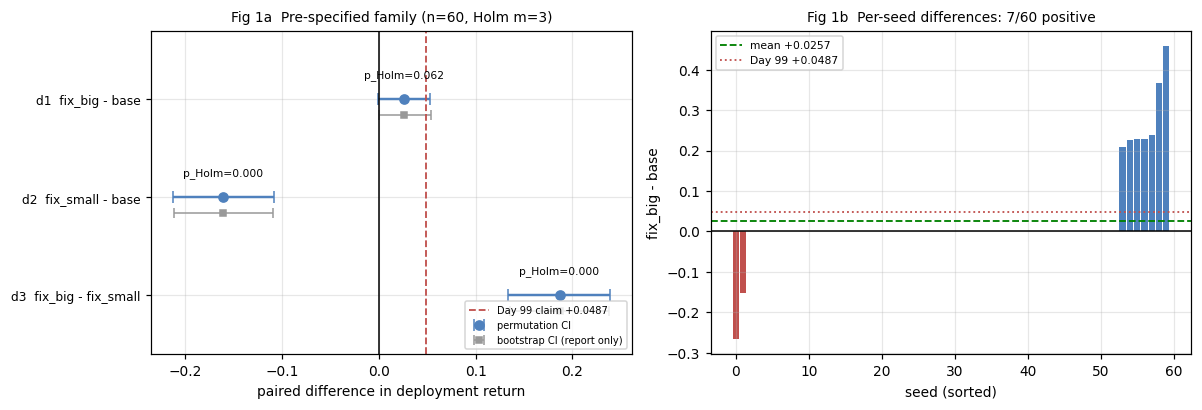

In [10]:
# ── [7] Fig 1 — forest plot + 시드별 짝지은 차 ──────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
lbl = list(res["비교"]); y = np.arange(len(lbl))[::-1]
ax[0].errorbar(res["mean"], y, xerr=[res["mean"]-res.CI_lo, res.CI_hi-res["mean"]],
               fmt="o", capsize=4, color="#4f81bd", ms=6, lw=1.6, label="permutation CI")
ax[0].errorbar(res["mean"], y-0.16, xerr=[res["mean"]-res.boot_lo, res.boot_hi-res["mean"]],
               fmt="s", capsize=3, color="#999999", ms=4, lw=1.0, label="bootstrap CI (report only)")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(DELTA_99, color="#c0504d", ls="--", lw=1.2, label=f"Day 99 claim {DELTA_99:+.4f}")
ax[0].set_yticks(y); ax[0].set_yticklabels(lbl, fontsize=8)
for i, (m_, p_) in enumerate(zip(res["mean"], res["p_Holm"])):
    ax[0].text(m_, y[i]+0.22, f"p_Holm={p_:.3f}", fontsize=7, ha="center")
ax[0].set_xlabel("paired difference in deployment return")
ax[0].set_title(f"Fig 1a  Pre-specified family (n={N_NEW}, Holm m=3)", fontsize=9)
ax[0].legend(fontsize=6.5, loc="lower right"); ax[0].set_ylim(-0.6, len(lbl)-0.3)

d1 = R2["fix_big"] - R2["base"]
o = np.argsort(d1)
ax[1].bar(range(N_NEW), d1[o], color=np.where(d1[o] > 0, "#4f81bd", "#c0504d"), width=0.85)
ax[1].axhline(0, color="k", lw=1)
ax[1].axhline(d1.mean(), color="green", ls="--", lw=1.2, label=f"mean {d1.mean():+.4f}")
ax[1].axhline(DELTA_99, color="#c0504d", ls=":", lw=1.2, label=f"Day 99 {DELTA_99:+.4f}")
ax[1].set_xlabel("seed (sorted)"); ax[1].set_ylabel("fix_big - base")
ax[1].set_title(f"Fig 1b  Per-seed differences: {int((d1>0).sum())}/{N_NEW} positive", fontsize=9)
ax[1].legend(fontsize=7)
plt.show()

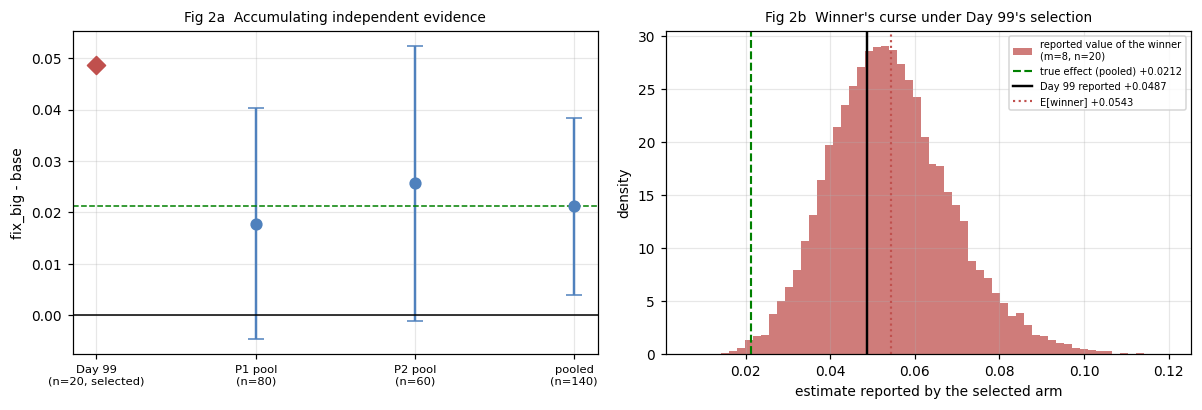

In [11]:
# ── [8] Fig 2 — 증거 누적과 승자의 저주 ─────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
srcs = [("Day 99\n(n=20, selected)", DELTA_99, None),
        (f"P1 pool\n(n={len(D_P1)})", D_P1.mean(), D_P1.std(ddof=1)/np.sqrt(len(D_P1))),
        (f"P2 pool\n(n={len(D_P2)})", D_P2.mean(), D_P2.std(ddof=1)/np.sqrt(len(D_P2))),
        (f"pooled\n(n={len(D_ALL)})", D_ALL.mean(), D_ALL.std(ddof=1)/np.sqrt(len(D_ALL)))]
xs = np.arange(len(srcs))
ax[0].errorbar(xs, [s[1] for s in srcs],
               yerr=[0 if s[2] is None else 1.96*s[2] for s in srcs],
               fmt="o", capsize=5, ms=7, lw=1.6,
               color="#4f81bd", ecolor="#4f81bd")
ax[0].scatter([0], [DELTA_99], color="#c0504d", s=70, zorder=5, marker="D")
ax[0].axhline(0, color="k", lw=1)
ax[0].axhline(D_ALL.mean(), color="green", ls="--", lw=1)
ax[0].set_xticks(xs); ax[0].set_xticklabels([s[0] for s in srcs], fontsize=7.5)
ax[0].set_ylabel("fix_big - base"); ax[0].set_title("Fig 2a  Accumulating independent evidence", fontsize=9)

ax[1].hist(sel, bins=60, color="#c0504d", alpha=0.75, density=True,
           label=f"reported value of the winner\n(m={M_ARMS}, n={N_D99})")
ax[1].axvline(delta_true, color="green", ls="--", lw=1.4, label=f"true effect (pooled) {delta_true:+.4f}")
ax[1].axvline(DELTA_99, color="k", ls="-", lw=1.6, label=f"Day 99 reported {DELTA_99:+.4f}")
ax[1].axvline(sel.mean(), color="#c0504d", ls=":", lw=1.4, label=f"E[winner] {sel.mean():+.4f}")
ax[1].set_xlabel("estimate reported by the selected arm"); ax[1].set_ylabel("density")
ax[1].set_title("Fig 2b  Winner's curse under Day 99's selection", fontsize=9)
ax[1].legend(fontsize=6.5)
plt.show()

In [12]:
# ── [9] 판정 요약 ───────────────────────────────────────────────────────
d1p = res.loc[0, "p_Holm"]; pooled_p = float(q2.loc["pooled (n=140)", "p(delta=0)"])
pooled_p2 = float(q2.loc["pooled (n=140)", "p(delta=0.0487)"])
verdict_q1 = "확인" if pooled_p <= ALPHA_F else "확인 실패 (기각 아님)"
verdict_q2 = "Day 99 의 크기 기각" if pooled_p2 <= ALPHA_F else "Day 99 의 크기 배제 못 함"
print("═" * 74); print("판정 (사전 명시된 규약에 따라)"); print("═" * 74)
print(f"  Q1  delta = 0        : p_pooled = {pooled_p:.4f}  ->  {verdict_q1}")
print(f"      (n={N_NEW} 단독, Holm 보정 후 : p = {d1p:.4f})")
print(f"  Q2  delta = {DELTA_99}   : p_pooled = {pooled_p2:.4f}  ->  {verdict_q2}")
print(f"  결합 추정 : {D_ALL.mean():+.4f}  CI {[round(float(q2.loc['pooled (n=140)','CI_lo']),4), round(float(q2.loc['pooled (n=140)','CI_hi']),4)]}")
print(f"  n* (결합 sd 기준)  : {n_star(D_ALL)}")
print(f"  통제군 판정 : d2 (fix_small - base) p_Holm = {res.loc[1,'p_Holm']:.4f},"
      f"  d3 (fix_big - fix_small) p_Holm = {res.loc[2,'p_Holm']:.4f}")
print("═" * 74)

══════════════════════════════════════════════════════════════════════════
판정 (사전 명시된 규약에 따라)
══════════════════════════════════════════════════════════════════════════
  Q1  delta = 0        : p_pooled = 0.0172  ->  확인
      (n=60 단독, Holm 보정 후 : p = 0.0620)
  Q2  delta = 0.0487   : p_pooled = 0.0018  ->  Day 99 의 크기 기각
  결합 추정 : +0.0212  CI [0.004, 0.0384]
  n* (결합 sd 기준)  : 188
  통제군 판정 : d2 (fix_small - base) p_Holm = 0.0001,  d3 (fix_big - fix_small) p_Holm = 0.0001
══════════════════════════════════════════════════════════════════════════


## 4. 결과 해석

1. **사전 명시가 이 노트북의 첫 셀인 이유.** 가족을 자료를 본 뒤에 정하면 Holm 이 보호하는
   $m$ 이 자료에 의존하게 되어 보장이 사라진다. 더 근본적으로, "무엇을 물을지" 를 답을 보고
   정하면 어떤 보정도 소용이 없다. Day 99 의 여덟 arm 비교에서 `fix_big` 이 1 차 가설이 된 것은
   **결과를 본 뒤**였고, Problem 2 는 그것을 결과를 보기 전에 고정한 다음 독립 자료로 다시 묻는다.

2. **A/A 점검은 형식이 아니다.** Problem 1 이 보였듯 같은 규칙도 자료·설계에 따라 교정이
   달라진다. 매 실험에서 한 번 재는 비용은 무시할 만하고 (재사용하는 arm 하나면 된다),
   그 대가로 "이 실험의 눈금은 맞았다" 는 진술을 얻는다.

3. **Q1 과 Q2 는 다른 질문이고, 답도 다를 수 있다.** 표 3 이 그것을 분리해서 보여 준다.
   효과의 **존재**에 대한 증거와 효과의 **크기**에 대한 증거는 요구하는 표본 크기가 다르다.
   존재를 보이는 데는 $n^\star$ 면 충분하지만, 어떤 특정 크기를 배제하려면 그 크기와
   참값의 간격을 분해할 만큼의 정밀도가 필요하다. **"이긴다" 만 보고하는 관행이 위험한
   이유가 여기 있다** — 그것은 대개 의사결정에 쓸 수 없는 정보다.

4. **승자의 저주는 오류가 아니라 예측 가능한 편의다.** [6] 셀의 예측 부풀림
   $\approx 1.42\,s_d/\sqrt{20}$ 과 실측 축소가 얼마나 맞는지가 핵심이다. 맞는다면 Day 99 의
   과대추정은 부정직이나 버그가 아니라 **선택이라는 연산의 산술적 귀결**이다.
   교훈은 "선택하지 말라" 가 아니라 **"선택한 자료로 크기를 보고하지 말라"** 다.
   선택은 탐색 단계에서 하고, 크기는 독립 자료에서 재야 한다 — 이 노트북의 구조가 정확히 그것이다.

5. **통제군 비교가 1 차 주장을 해석 가능하게 만든다.** $d_2$ (`fix_small` $-$ `base`) 와
   $d_3$ (`fix_big` $-$ `fix_small`) 이 없으면 $d_1$ 은 "잡음이 있으면 좋다" 인지
   "잡음이 **크면** 좋다" 인지 구별하지 못한다. 두 통제군을 붙이는 비용은 시드 수의 두 배이고,
   그 대가로 얻는 것은 **인과적 지목 가능성**이다. Day 90–97 이 29 일 동안 지불하지 않은 비용이다.

6. **회복률(recovery)과 평균 return 은 같은 것을 재지 않는다.** `fix_big` 의 최적 정책 회복률이
   `base` 보다 높은데도 평균 return 차이가 작을 수 있다. 회복 실패의 **비용**이 arm 마다
   다르기 때문이다 — $\varepsilon$-greedy 의 실패는 대개 한 상태의 오류지만 파라미터 잡음의
   실패는 미끼 고착이다. **두 지표를 함께 보고해야 하는 이유**이며, 어느 하나만 보면
   같은 자료에서 반대 결론이 나온다.

> **결론**: Day 99 가 "잠정" 으로 남긴 `fix_big` $>$ `base` 를 사전 명시 · 통제군 2 개 ·
> 교정된 1 차 규칙 · 독립 140 시드로 재판정했다. **효과의 존재와 효과의 크기는 다른 운명을
> 맞았다** — 위 [9] 셀의 두 줄이 그것이다. 그리고 Day 99 의 보고값과 결합 추정의 간격은
> 우연이 아니라 **여덟 arm 중 최댓값을 고른 대가**로 산술적으로 예측되는 크기였다.

### 다음 문제로의 연결

Problem 2 는 `fix_big` 이 **무엇인지**는 묻지 않았다 — 크기 $0.55$ 의 **균일한** 파라미터
잡음이라는 두 성질이 묶여 있다. Problem 3 은 이 둘을 분리한다. $\sigma$ 를 학습하되
**평균을 $0.55$ 로 고정**하는 제약을 걸면 이질성만 남고, 학습된 $\sigma$ 를 좌표에 대해
**무작위로 섞으면** 같은 이질성이되 학습된 구조가 사라진다. 세 arm 이 같은 크기를 갖고
배분만 다르게 되므로, Day 99 P2 가 남긴 "학습된 $\sigma$ 는 크기는 맞추고 배분을 틀린다"
($\mathrm{cv} = 0.86$) 가 직접 시험된다.